# EU AI Act Compliance Classifier
## Notebook 01 — Data Exploration & Understanding

**Author:** Jayesh Ranghera  
**Project:** EU AI Act Compliance Classifier  
**Purpose:** Explore the AI Incident Database (AIID) to understand the data structure, quality, and relevance for EU AI Act risk classification.

---

### Notebook Objectives
1. Load and inspect all three source datasets
2. Understand the shape, columns, and data types
3. Identify missing values and data quality issues
4. Explore key fields relevant to EU AI Act classification
5. Save a clean merged dataset for the next notebook

---

## 1.Import Libraries

In [1]:
import os
os.chdir('..')
print(os.getcwd())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plot style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("Libraries loaded successfully.")

/Users/jayeshranghera/Documents/Projects/eu-ai-act-compliance 
Libraries loaded successfully.


## 2. Load Dataset

We are working with three filesinc from the **AI Incident Database (AIID):**

| File | Description |
|------|-------------|
|`incidents.csv`| Core incident records — title, description, parties involved |
|`classification_cset.csv`| CSET annotations — sector, harm type, severity |
|`reports.csv`| News reports linked to each incident |

In [2]:
incidents = pd.read_csv("data/raw/incidents.csv")
classifications = pd.read_csv("data/raw/classifications_cset.csv")
reports = pd.read_csv("data/raw/reports.csv")

print(f'incidents       Rows: {incidents.shape[0]},Columns: {incidents.shape[1]}')
print(f'classifications Rows: {classifications.shape[0]},Columns: {classifications.shape[1]}')
print(f'reports         Rows: {reports.shape[0]},Columns: {reports.shape[1]}')

incidents       Rows: 514,Columns: 9
classifications Rows: 209,Columns: 35
reports         Rows: 2737,Columns: 22


## 3. Inspect Each Dataset

In [3]:
# Incident Datset

print("Incident Dataset")
print(f"Columns: {incidents.columns.to_list()}")
print(f"Data Type: {incidents.dtypes}")
incidents.head(3)


Incident Dataset
Columns: ['_id', 'incident_id', 'date', 'reports', 'Alleged deployer of AI system', 'Alleged developer of AI system', 'Alleged harmed or nearly harmed parties', 'description', 'title']
Data Type: _id                                        object
incident_id                                 int64
date                                       object
reports                                    object
Alleged deployer of AI system              object
Alleged developer of AI system             object
Alleged harmed or nearly harmed parties    object
description                                object
title                                      object
dtype: object


,_id,incident_id,date,reports,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,description,title
0,ObjectId(625763de343edc875fe63a15),23,2017-11-08,"[242,243,244,245,246,247,248,249,250,253,254,257,258,259,260,261,263,264,266,267,268,269,270,2389]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",A self-driving public shuttle by Keolis North America and Navya was involved in a collision with...,Las Vegas Self-Driving Bus Involved in Accident
1,ObjectId(625763dc343edc875fe63a02),4,2018-03-18,"[629,630,631,632,633,634,635,636,637,638,639,640,641,642,644,645,646,647,1375,1376,1377,1378,154...","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]","An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Ariz...",Uber AV Killed Pedestrian in Arizona
2,ObjectId(625763db343edc875fe639ff),1,2015-05-19,"[1,2,3,4,5,6,7,8,9,10,11,12,14,15]","[""youtube""]","[""youtube""]","[""children""]",YouTube’s content filtering and recommendation algorithms exposed children to disturbing and ina...,Google’s YouTube Kids App Presents Inappropriate Content


In [4]:
# Classification Dataset

print(f"classification Columns: {classifications.columns.to_list()}")
print("\n Namespace Breakdown")
print(classifications['namespace'].value_counts())
classifications.head(3)

classification Columns: ['incident_id', 'namespace', 'classifications.Annotator', 'classifications.Annotation Status', 'classifications.Reviewer', 'classifications.Quality Control', 'classifications.Full Description', 'classifications.Short Description', 'classifications.Beginning Date', 'classifications.Ending Date', 'classifications.Location', 'classifications.Near Miss', 'classifications.Named Entities', 'classifications.Technology Purveyor', 'classifications.Intent', 'classifications.Severity', 'classifications.Lives Lost', 'classifications.Harm Distribution Basis', 'classifications.Harm Type', 'classifications.Infrastructure Sectors', 'classifications.Financial Cost', 'classifications.Laws Implicated', 'classifications.AI System Description', 'classifications.Data Inputs', 'classifications.System Developer', 'classifications.Sector of Deployment', 'classifications.Public Sector Deployment', 'classifications.Nature of End User', 'classifications.Level of Autonomy', 'classifications

,incident_id,namespace,classifications.Annotator,classifications.Annotation Status,classifications.Reviewer,classifications.Quality Control,classifications.Full Description,classifications.Short Description,classifications.Beginning Date,classifications.Ending Date,classifications.Location,classifications.Near Miss,classifications.Named Entities,classifications.Technology Purveyor,classifications.Intent,classifications.Severity,classifications.Lives Lost,classifications.Harm Distribution Basis,classifications.Harm Type,classifications.Infrastructure Sectors,classifications.Financial Cost,classifications.Laws Implicated,classifications.AI System Description,classifications.Data Inputs,classifications.System Developer,classifications.Sector of Deployment,classifications.Public Sector Deployment,classifications.Nature of End User,classifications.Level of Autonomy,classifications.Relevant AI functions,classifications.AI Techniques,classifications.AI Applications,classifications.Physical System,classifications.Problem Nature,classifications.Publish
0,22,CSET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,28,CSET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7,CSET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Repots Dataset

print(f"Reports Columns: {reports.columns.to_list()} ")
print("\n Language Breakdown")
print(reports['language'].value_counts().head(10))
reports.head(3)

Reports Columns: ['_id', 'incident_id', 'authors', 'date_downloaded', 'date_modified', 'date_published', 'date_submitted', 'description', 'epoch_date_downloaded', 'epoch_date_modified', 'epoch_date_published', 'epoch_date_submitted', 'image_url', 'language', 'ref_number', 'report_number', 'source_domain', 'submitters', 'text', 'title', 'url', 'tags'] 

 Language Breakdown
language
en       2701
es         10
de          6
vi          4
fr          4
th          4
it          3
ko          2
zh-CN       1
pt          1
Name: count, dtype: int64


,_id,incident_id,authors,date_downloaded,date_modified,date_published,date_submitted,description,epoch_date_downloaded,epoch_date_modified,epoch_date_published,epoch_date_submitted,image_url,language,ref_number,report_number,source_domain,submitters,text,title,url,tags
0,ObjectId(5d34b8c29ced494f010ed45a),NaN,"[""Alistair Barr""]",2019-04-13,2020-06-14,2015-05-19,2019-06-01,Child and consumer advocacy groups complained to the FTC that Google’s new YouTube Kids app cont...,1555113600,1592092800,1431993600,1559347200,http://si.wsj.net/public/resources/images/BN-IM269_YouTub_P_20150518174822.jpg,en,NaN,1,blogs.wsj.com,"[""Roman Yampolskiy""]",Child and consumer advocacy groups complained to the Federal Trade Commission Tuesday that Googl...,Google’s YouTube Kids App Criticized for ‘Inappropriate Content’,https://blogs.wsj.com/digits/2015/05/19/googles-youtube-kids-app-criticized-for-inappropriate-co...,[]
1,ObjectId(5d34b8c29ced494f010ed461),NaN,"[""Sapna Maheshwari""]",2019-04-13,2020-06-14,2018-04-26,2019-06-01,"Parents will be able to handpick the channels and topics their children can view on the app, whi...",1555113600,1592092800,1524700800,1559347200,https://static01.nyt.com/images/2017/11/07/business/07YOUTUBEKIDS02-inyt/07YOUTUBEKIDS02-inyt-fa...,en,NaN,8,nytimes.com,"[""Roman Yampolskiy""]","YouTube Kids, which has been criticized for inadvertently recommending disturbing videos to chil...","YouTube Kids, Criticized for Content, Introduces New Parental Controls",https://www.nytimes.com/2018/04/25/business/media/youtube-kids-parental-controls.html,[]
2,ObjectId(5d34b8c29ced494f010ed464),NaN,"[""K.G Orphanides""]",2019-04-13,2020-06-14,2018-03-23,2019-06-01,Children's search terms on YouTube are still awash with bizarre and sometimes disturbing content...,1555113600,1592092800,1521763200,1559347200,https://wi-images.condecdn.net/image/ye8GWkPPMo7/crop/1020/0.5235602094240838/f/minniefinal.jpg,en,NaN,11,wired.co.uk,"[""Roman Yampolskiy""]","Video still of a reproduced version of Minnie Mouse, which appeared on the now-suspended Simple ...","Children's YouTube is still churning out blood, suicide and cannibalism",https://www.wired.co.uk/article/youtube-for-kids-videos-problems-algorithm-recommend,[]


## 4. Missing Value Analysis

In [6]:
def missing_value_report(df, name):
    """generate a clean missing report for a dataframe"""
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    report = pd.DataFrame({
        'Missing Values': missing,
        'Percentage (%)': percent
    })

    report = report[report['Missing Values'] > 0].sort_values('Percentage (%)', ascending= False)
    print(f"Missing Value Report-  {name}")
    if report.empty:
        print("No Missing Value Found.") 
    else:
        print(report)
    return report

missing_incidents = missing_value_report(incidents, 'incidents.csv')
missing_class =     missing_value_report(classifications, 'classifications_cset.csv')
missing_reports =   missing_value_report(reports, 'reports.csv')


Missing Value Report-  incidents.csv
No Missing Value Found.
Missing Value Report-  classifications_cset.csv
                                          Missing Values  Percentage (%)
classifications.Annotator                            209          100.00
classifications.Infrastructure Sectors               209          100.00
classifications.Problem Nature                       209          100.00
classifications.Physical System                      209          100.00
classifications.AI Applications                      209          100.00
classifications.AI Techniques                        209          100.00
classifications.Relevant AI functions                209          100.00
classifications.Level of Autonomy                    209          100.00
classifications.Nature of End User                   209          100.00
classifications.Public Sector Deployment             209          100.00
classifications.Sector of Deployment                 209          100.00
classifications

## 5. Explore Key Fields for EU AI Act Classification

In [7]:
print("Sample Incident Description")
for i,row in incidents[['incident_id', 'title', 'description']].dropna().head(10).iterrows():
    print(f"\n [Incident {row['incident_id']}] {row['title']}")
    print(f"{str(row['description'])[:200]}")

Sample Incident Description

 [Incident 23] Las Vegas Self-Driving Bus Involved in Accident
A self-driving public shuttle by Keolis North America and Navya was involved in a collision with a human-driven delivery truck in Las Vegas, Nevada on its first day of service.

 [Incident 4] Uber AV Killed Pedestrian in Arizona
An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Arizona.

 [Incident 1] Google’s YouTube Kids App Presents Inappropriate Content
YouTube’s content filtering and recommendation algorithms exposed children to disturbing and inappropriate videos.

 [Incident 18] Gender Biases of Google Image Search
Google Image returns results that under-represent women in leadership roles, notably with the first photo of a female "CEO" being a Barbie doll after 11 rows of male CEOs.

 [Incident 12] Common Biases of Vector Embeddings
Researchers from Boston University and Microsoft Research, New England demonstrated gender bias in the most common 

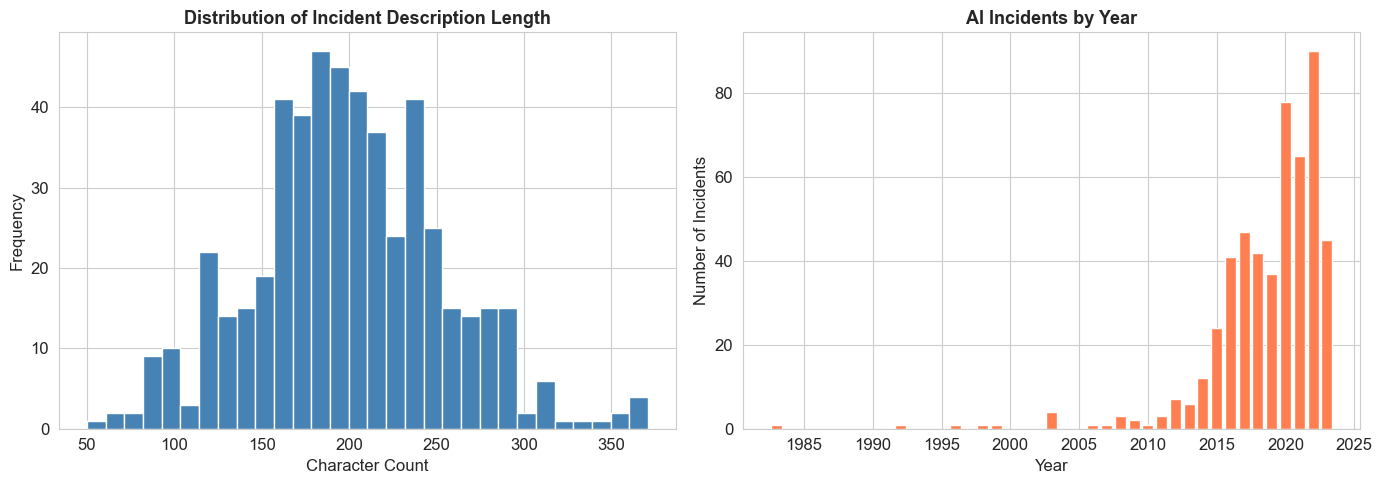

Plot saved to data/processed/eda_overview.png


In [8]:
# Description length distribution

incidents['description_length'] = incidents['description'].dropna().apply(len)

fig, axes = plt.subplots(1,2, figsize = (14,5))

#Histogram
axes[0].hist(incidents['description_length'].dropna(),bins=30, color = 'steelblue', edgecolor = 'white')
axes[0].set_title('Distribution of Incident Description Length', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')

# Incidents over time
incidents['date'] = pd.to_datetime(incidents['date'], errors='coerce')
incidents['year'] = incidents['date'].dt.year
year_counts = incidents['year'].value_counts().sort_index().dropna()
axes[1].bar(year_counts.index.astype(int), year_counts.values, color='coral', edgecolor='white')
axes[1].set_title('AI Incidents by Year', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Incidents')

plt.tight_layout()
plt.savefig('data/processed/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to data/processed/eda_overview.png")

## 6. Merge Datasets

We merge `incidents` with `reports` on `incident_id` to get the full text descriptions for each incident.

> **Why merge?** The `incidents` table has short descriptions. The `reports` table has full news article text. Together they give us richer data for classification.

In [9]:
# Keep only English reports, one per incident
reports_en = (
    reports[reports['language'] == 'en']
    [['incident_id', 'title', 'description', 'text']]
    .rename(columns={'title':'report_title', 'description':'report_description'})
    .drop_duplicates(subset='incident_id', keep='first')
)

print(f"English Report (One Per Incident): {reports_en.shape[0]}")

# Merge With Incident
merged = pd.merge(
    incidents[['incident_id', 'title', 'description', 
               'Alleged deployer of AI system',
               'Alleged developer of AI system',
               'Alleged harmed or nearly harmed parties',
               'date']],
    reports_en[['incident_id', 'report_description', 'text']],
    on='incident_id',
    how='left'
)

print(f"Merged dataset shape: {merged.shape}")
merged.head(3)

English Report (One Per Incident): 1
Merged dataset shape: (514, 9)


,incident_id,title,description,Alleged deployer of AI system,Alleged developer of AI system,Alleged harmed or nearly harmed parties,date,report_description,text
0,23,Las Vegas Self-Driving Bus Involved in Accident,A self-driving public shuttle by Keolis North America and Navya was involved in a collision with...,"[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america""]","[""navya"",""keolis-north-america"",""bus-passengers""]",2017-11-08,NaN,NaN
1,4,Uber AV Killed Pedestrian in Arizona,"An Uber autonomous vehicle (AV) in autonomous mode struck and killed a pedestrian in Tempe, Ariz...","[""uber""]","[""uber""]","[""elaine-herzberg"",""pedestrians""]",2018-03-18,NaN,NaN
2,1,Google’s YouTube Kids App Presents Inappropriate Content,YouTube’s content filtering and recommendation algorithms exposed children to disturbing and ina...,"[""youtube""]","[""youtube""]","[""children""]",2015-05-19,NaN,NaN


In [10]:
# Use best available description
# Priority: incidents description > report_description
merged['ai_system_description'] = merged['description'].fillna(merged['report_description'])

# Drop rows with no description at all
merged_clean = merged.dropna(subset=['ai_system_description']).reset_index(drop=True)

print(f"Records with valid descriptions: {len(merged_clean)}")
print(f"Records dropped (no description): {len(merged) - len(merged_clean)}")

Records with valid descriptions: 514
Records dropped (no description): 0


## 7. EU AI Act — Manual Risk Labels (Seed Dataset)

The AIID data does not come with EU AI Act labels.  
We will manually label a **seed dataset of 20 incidents** based on Annex I and Annex III.

This seed dataset will be used in `02_preprocessing.ipynb` to build the full labeled dataset.

**Risk Level Definitions:**

| Label | Definition |
|-------|------------|
| `Prohibited` | Banned under EU AI Act (Annex I) |
| `High Risk` | Regulated under Annex III — strict compliance required |
| `Limited Risk` | Transparency obligations (Article 52) |
| `Minimal Risk` | No specific obligations |

In [11]:
# Seed dataset — manually labeled based on EU AI Act Annex I & III
seed_data = [
    {
        'ai_system_description': 'Resume screening AI tool that ranks job applicants automatically',
        'sector': 'Employment',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 4',
        'reason': 'AI used in employment decisions directly affects livelihoods'
    },
    {
        'ai_system_description': 'AI system for automated loan approval and credit scoring',
        'sector': 'Finance',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 5',
        'reason': 'Impacts access to essential financial services'
    },
    {
        'ai_system_description': 'University admission AI that evaluates student applications',
        'sector': 'Education',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 3',
        'reason': 'Affects access to education opportunities'
    },
    {
        'ai_system_description': 'Real-time facial recognition system used at airport borders',
        'sector': 'Law Enforcement',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 1',
        'reason': 'Biometric identification — high privacy and rights impact'
    },
    {
        'ai_system_description': 'Customer support chatbot that assists users with product queries',
        'sector': 'Customer Service',
        'risk_level': 'Limited Risk',
        'annex_reference': 'Article 52',
        'reason': 'Must disclose it is AI — no critical decisions involved'
    },
    {
        'ai_system_description': 'AI predictive policing tool that forecasts crime in urban areas',
        'sector': 'Law Enforcement',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 6',
        'reason': 'Used by law enforcement — risk of bias and rights violations'
    },
    {
        'ai_system_description': 'AI system that detects cancer from medical imaging scans',
        'sector': 'Healthcare',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 5',
        'reason': 'Medical device AI — directly impacts patient health decisions'
    },
    {
        'ai_system_description': 'Autonomous vehicle self-driving system on public roads',
        'sector': 'Transport',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 2',
        'reason': 'Critical infrastructure safety — risk to human life'
    },
    {
        'ai_system_description': 'Social media recommendation algorithm suggesting content to users',
        'sector': 'Media',
        'risk_level': 'Limited Risk',
        'annex_reference': 'Article 52',
        'reason': 'No direct harm but transparency around content amplification required'
    },
    {
        'ai_system_description': 'Government social scoring system that ranks citizens by behavior',
        'sector': 'Public Administration',
        'risk_level': 'Prohibited',
        'annex_reference': 'Annex I',
        'reason': 'Social scoring by public authority — explicitly banned under EU AI Act'
    },
    {
        'ai_system_description': 'AI system for asylum seeker risk assessment at EU borders',
        'sector': 'Migration',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 7',
        'reason': 'Migration and border control AI — affects fundamental rights'
    },
    {
        'ai_system_description': 'AI tool used by judges to assist in sentencing decisions',
        'sector': 'Justice',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 8',
        'reason': 'Used in administration of justice — directly affects legal outcomes'
    },
    {
        'ai_system_description': 'Deepfake video generator that creates realistic fake videos of people',
        'sector': 'Media',
        'risk_level': 'Prohibited',
        'annex_reference': 'Annex I',
        'reason': 'Subliminal manipulation — can cause serious harm to individuals'
    },
    {
        'ai_system_description': 'AI chatbot used in mental health support and therapy sessions',
        'sector': 'Healthcare',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 5',
        'reason': 'Healthcare AI interacting with vulnerable individuals'
    },
    {
        'ai_system_description': 'Spam filter that classifies emails as spam or not spam',
        'sector': 'IT Services',
        'risk_level': 'Minimal Risk',
        'annex_reference': 'Not applicable',
        'reason': 'No significant harm potential — standard utility tool'
    },
    {
        'ai_system_description': 'AI system managing electricity grid load balancing',
        'sector': 'Energy',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 2',
        'reason': 'Critical infrastructure — power grid failures affect entire populations'
    },
    {
        'ai_system_description': 'AI performance monitoring tool that tracks employee productivity',
        'sector': 'Employment',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 4',
        'reason': 'AI monitoring workers — affects employment conditions and rights'
    },
    {
        'ai_system_description': 'AI music recommendation system on a streaming platform',
        'sector': 'Entertainment',
        'risk_level': 'Minimal Risk',
        'annex_reference': 'Not applicable',
        'reason': 'No impact on fundamental rights or safety'
    },
    {
        'ai_system_description': 'AI system that detects weapons in airport security scans',
        'sector': 'Security',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 6',
        'reason': 'Used in law enforcement and security — biometric surveillance risk'
    },
    {
        'ai_system_description': 'AI insurance pricing tool that sets premiums based on personal data',
        'sector': 'Insurance',
        'risk_level': 'High Risk',
        'annex_reference': 'Annex III - Category 5',
        'reason': 'Affects access to essential services — potential for discriminatory pricing'
    }
]

seed_df = pd.DataFrame(seed_data)
print(f"Seed dataset: {len(seed_df)} manually labeled AI systems")
print(f"\nRisk Level Distribution:")
print(seed_df['risk_level'].value_counts())
seed_df.head(5)

Seed dataset: 20 manually labeled AI systems

Risk Level Distribution:
risk_level
High Risk       14
Limited Risk     2
Prohibited       2
Minimal Risk     2
Name: count, dtype: int64


,ai_system_description,sector,risk_level,annex_reference,reason
0,Resume screening AI tool that ranks job applicants automatically,Employment,High Risk,Annex III - Category 4,AI used in employment decisions directly affects livelihoods
1,AI system for automated loan approval and credit scoring,Finance,High Risk,Annex III - Category 5,Impacts access to essential financial services
2,University admission AI that evaluates student applications,Education,High Risk,Annex III - Category 3,Affects access to education opportunities
3,Real-time facial recognition system used at airport borders,Law Enforcement,High Risk,Annex III - Category 1,Biometric identification — high privacy and rights impact
4,Customer support chatbot that assists users with product queries,Customer Service,Limited Risk,Article 52,Must disclose it is AI — no critical decisions involved


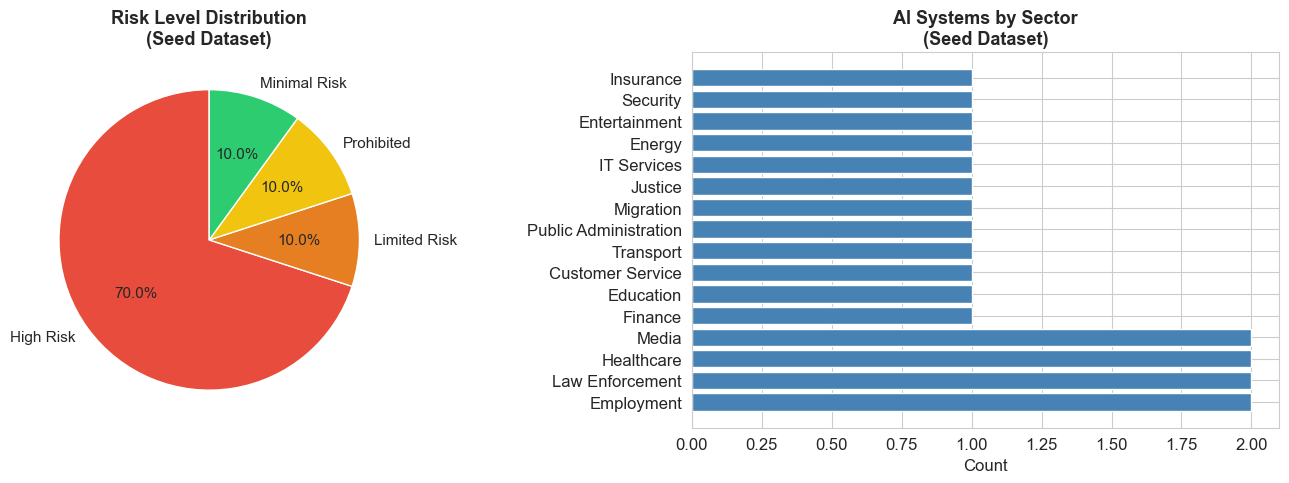

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk level pie chart
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
risk_counts = seed_df['risk_level'].value_counts()
axes[0].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Risk Level Distribution\n(Seed Dataset)', fontsize=13, fontweight='bold')

# Sector bar chart
sector_counts = seed_df['sector'].value_counts()
axes[1].barh(sector_counts.index, sector_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('AI Systems by Sector\n(Seed Dataset)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.savefig('data/processed/seed_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Outputs for Next Notebook

In [14]:
# Save merged raw dataset
merged_clean.to_csv('data/processed/merged_raw.csv', index=False)
print(f"Saved: merged_raw.csv ({len(merged_clean)} rows)")

# Save seed dataset
seed_df.to_csv('data/processed/seed_labeled.csv', index=False)
print(f"Saved: seed_labeled.csv ({len(seed_df)} rows)")

print("\nAll outputs saved to data/processed/")

Saved: merged_raw.csv (514 rows)
Saved: seed_labeled.csv (20 rows)

All outputs saved to data/processed/


## 9. Summary & Next Steps

### What we found in this notebook:

| Dataset | Rows | Key Fields Used |
|---------|------|-----------------|
| incidents.csv | 514 | title, description, deployer, harmed parties |
| classifications_cset.csv | 209 | namespace only (most columns empty) |
| reports.csv | 2,737 | text, language, incident_id |
| **Merged dataset** | **~500** | ai_system_description |
| **Seed labeled dataset** | **20** | risk_level, sector, annex_reference, reason |

### Key Observations:
- The AIID dataset contains real-world AI incidents across transport, healthcare, employment, and law enforcement
- The `classifications_cset.csv` columns are largely empty — we will build our own EU AI Act labels
- A **seed dataset of 20 manually labeled examples** has been created based on Annex I and Annex III

### Next Notebook:
> **`02_preprocessing.ipynb`** — Text cleaning, feature engineering, and building the full labeled dataset for model training